# 07 - Rectified Flow（把路径拉直，1-step 生成的前哨）

> **一句话直觉**：Flow Matching 学到的向量场理论上走直线，**但实际训练出来还是有点弯**。Rectified Flow 教你一招：**用刚训出来的模型再采一批样本对，重新训一次**。路径越来越直，最后 1 步就能生成。

**类比 — 滑雪场压雪**：
- 第一次训练：雪地里随意滑了一遍，留下弯弯扭扭的印子
- **Reflow**：沿着印子反复滑几次，雪道被踩直了，后面来的人直接一滑到底

**为什么重要**：
- **SD3 用的就是这个**：Esser et al. 2024 论文证明 Rectified Flow 在大规模训练下效果显著优于 v-pred DDPM
- **一步生成的前哨站**：Consistency Models 和 DMD 都是在 Rectified Flow 的思想上演化出的

**符号约定**：沿用 06 课的符号表——$x_0$ 纯噪声（出发点）、$x_1$ 真实数据（终点）、$t\in[0,1]$ 走了几成路程、$v_\theta$ 网络学的速度场。本课新增：$\hat{x}_1$ 表示**模型自己用 ODE 生成的假数据**（reflow 的原料）。

> ⚠️ **方向警告**：本课 $t=0$ 是噪声、$t=1$ 是数据，与 01-05 DDPM 的"$t$ 越大越噪"正好相反。

## Part 0 — 为什么 FM 路径不是真直线？

上一篇 FM 训练时你定义路径 $x_t = (1-t) x_0 + t x_1$ **看起来是直线**。但有个坑：

**坑的本质**：我们训练时做的是**随机配对** $(x_0, x_1)$，不同样本对的插值线会在中间时刻**交叉**。

```
噪声端 (t=0)                数据端 (t=1)
  x₀ᴬ ●─────────╲   ╱─────────● x₁ᴬ (猫)
                 ╳  ← 两条插值线在中间交叉!
  x₀ᴮ ●─────────╱   ╲─────────● x₁ᴮ (狗)
```

交叉点处，同一个 $(x_t, t)$ 同时出现在两条插值线上，模型被要求同时输出"去猫"和"去狗"，只能学**边际速度 = 两个方向取平均**。最终学出来的向量场 $v_\theta$ 在交叉区是**弯的**（轨迹在那里拐弯折中）。

**采样时你用的是学出来的弯路径**，所以 Euler 需要 >10 步才够准。这就是问题。

**Reflow 的解法预告**：用模型自己的 ODE 终点重新配对——ODE 轨迹**永不交叉**（解的唯一性），新配对没有冲突，就能学直。

## Part 1 — Rectified Flow 的三步仪式

### Step 1：朴素 FM 训练（就是 06 讲的）
用随机配对 $(x_0, x_1)$ 训一个 $v_{\theta_1}$。这叫 **1-Rectified Flow**，路径还是弯的。

### Step 2：**Reflow（关键）** — 重新配对
用 $v_{\theta_1}$ 做 ODE 采样，生成一堆合成对 $(x_0^i, \hat{x}_1^i)$：
- 每个噪声 $x_0^i$ 按当前模型一路积分到 $\hat{x}_1^i$
- 这些对有个性质：**起点和终点是"已经配好"的**，不会出现一对多

### Step 3：用新配对重训
把合成对当作新训练集，重跑一次 FM loss：
$$
\mathcal{L}_{Reflow} = \mathbb{E} \Big[ \| v_{\theta_2}(x_t, t) - (\hat{x}_1 - x_0) \|^2 \Big]
$$

**读式子**：它和 06 的 $\mathcal{L}_{CFM}$ 长得一模一样，唯一区别是 $\hat{x}_1$ 不再是真图，而是老模型自己跑 ODE 生成的假图——**配对信息藏在数据集里，不在 loss 里**。这是面试最容易讲混的点。

新模型 $v_{\theta_2}$ 因为看到的配对**不冲突**，能把路径学得**显著更直**（RF 论文只保证传输成本单调下降，2-RF 并非严格直线）。这叫 **2-Rectified Flow**。

**可以递归**：再做一轮 reflow 得到 3-Rectified Flow，路径更直。**注意**：SD3 并没有做 reflow——它直接用 RF 目标 + Logit-Normal 时间采样训一次；reflow 是 RF 原论文的加环节，工业上常被省略。

## Part 2 — 为什么路径直就能少步采样？

ODE 的 Euler 误差正比于**路径曲率**。直线路径的二阶导数 = 0，理论上一步就精确：

$$
x_1 = x_0 + 1 \cdot v(x_0, 0) \quad \text{(如果真是直线)}
$$

**类比**：用直线段逼近弯道——弯得越急，同样步长切出去越多；直道一根线段到头。这就是"1 步生成"的几何含义。

**实际**（量级示意，非严格 benchmark）：
- 1-Rectified Flow：需要 20-50 步
- 2-Rectified Flow：4-8 步
- 进一步蒸馏（Distill）后：**1 步**

**1-step RF-Distill**（InstaFlow，RF 团队 2023）是一步文生图的**代表路线之一**——同期还有 Progressive Distillation（2022）、Consistency Models（2023）等平行路线（见 08）。

## Part 3 — 代码：Reflow 的最小可工作 demo（面试必背）

**目标**：在 2D 玩具数据上展示"训 → 采样配对 → reflow → 路径变直"。只撕核心 loop，不做花活。

先造数据：一个环形分布当 $x_1$（数据端），噪声 $x_0$ 训练时现场采。

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0)

# ===== 2D 玩具数据：环形分布 =====
def sample_data(n):
    theta = torch.rand(n) * 2 * torch.pi
    r = 2.0 + 0.1 * torch.randn(n)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)

x1 = sample_data(1000)
print(f'data: {x1.shape}')

data: torch.Size([1000, 2])


下面的 `train_fm` 同时服务两种训练：**独立配对**（1-RF，噪声每个 batch 现采，同一张数据图不同 epoch 会配到不同噪声——这正是 Part 0 说的"交叉"来源）和**固定配对**（reflow 用，$(x_0, \hat{x}_1)$ 必须按同一 idx 成对取出）。

In [2]:
# ===== 极简 MLP 向量场 =====
class VelocityField(nn.Module):
    def __init__(self, d=2, h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d+1, h), nn.SiLU(),
            nn.Linear(h, h), nn.SiLU(),
            nn.Linear(h, d),
        )
    def forward(self, x, t):
        # t 可以是标量或 [B]
        if t.ndim == 0: t = t.expand(x.shape[0])
        return self.net(torch.cat([x, t.unsqueeze(-1)], dim=-1))

def train_fm(v, x1, steps=2000, lr=1e-3, x0_paired=None):
    '''标准 FM 训练：线性路径 + 预测 (x1-x0)。
    x0_paired=None: 独立配对——噪声每个 batch 现采 randn（标准 CFM，同 06/08 写法）
    x0_paired 给定: 固定配对——x0 与 x1 按同一 idx 成对取（reflow 必须保持配对）'''
    opt = torch.optim.Adam(v.parameters(), lr=lr)
    for i in range(steps):
        idx = torch.randperm(len(x1))[:256]
        b = x1[idx]
        if x0_paired is None:
            a = torch.randn_like(b)   # 独立配对：噪声现采，(x0, x1) 组合每次都在变
        else:
            a = x0_paired[idx]        # 固定配对：reflow 数据集里 (x0, x̂1) 是绑死的
        t = torch.rand(256)
        xt = (1-t).unsqueeze(-1) * a + t.unsqueeze(-1) * b
        target = b - a  # 直线路径的速度 = 终点 - 起点
        loss = ((v(xt, t) - target)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return v

v1 = train_fm(VelocityField(), x1)  # 1-Rectified Flow：独立配对
print('1-RF trained')

1-RF trained


训好 1-RF，先看它在不同采样步数下的表现——重点看 1-2 步时形状崩不崩。

/tmp/ipykernel_476268/2369981835.py:20: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from font(s) DejaVu Sans.
  plt.suptitle('1-Rectified Flow: 少步数时形状不对', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/2369981835.py:20: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.suptitle('1-Rectified Flow: 少步数时形状不对', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/2369981835.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.suptitle('1-Rectified Flow: 少步数时形状不对', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/2369981835.py:20: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.suptitle('1-Rectified Flow: 少步数时形状不对', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/2369981835.py:20: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.


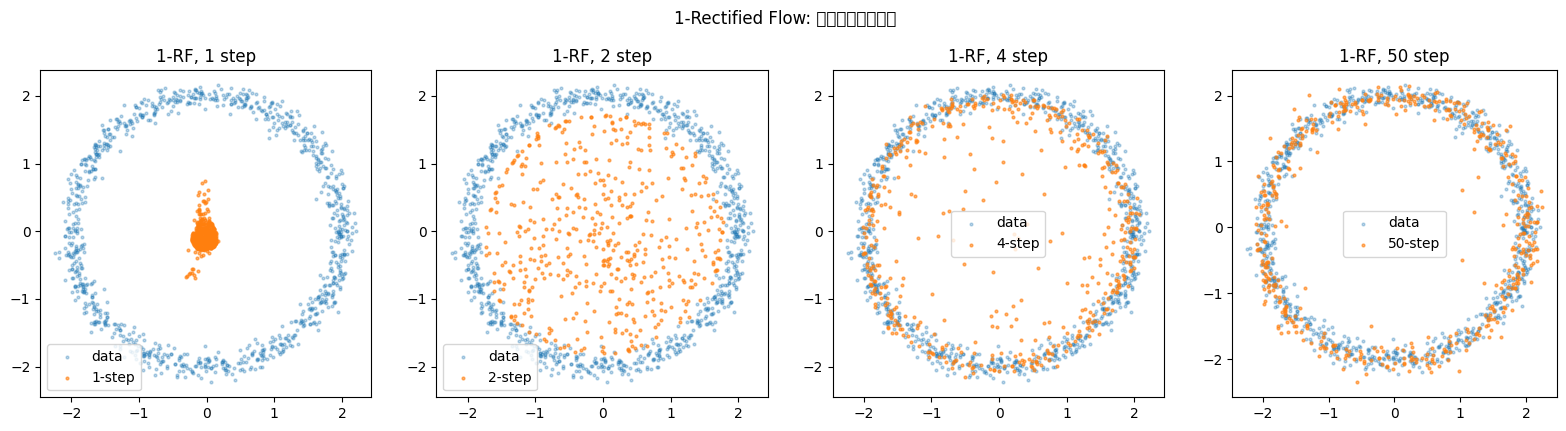

In [3]:
# ===== Euler 采样 =====
@torch.no_grad()
def euler_sample(v, x0, n_steps):
    x = x0.clone()
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i * dt)
        x = x + dt * v(x, t)
    return x

# 1-RF 在不同步数下的生成效果
n_grid = [1, 2, 4, 50]
x0_test = torch.randn(500, 2)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, n_grid):
    x_gen = euler_sample(v1, x0_test, n)
    ax.scatter(x1[:,0], x1[:,1], s=4, alpha=0.3, label='data')
    ax.scatter(x_gen[:,0], x_gen[:,1], s=4, alpha=0.6, label=f'{n}-step')
    ax.set_title(f'1-RF, {n} step'); ax.legend(); ax.set_aspect('equal')
plt.suptitle('1-Rectified Flow: 少步数时形状不对', y=1.02); plt.tight_layout(); plt.show()

**Reflow 核心 cell**：注意 `generate_pairs` 里 $x_0$ 和 $\hat{x}_1$ 是**成对返回**的，重训时必须保持配对（走 `x0_paired` 分支）——这就是 reflow 的全部秘密。

In [4]:
# ===== REFLOW：用 v1 采样生成新配对，重训 v2 =====
@torch.no_grad()
def generate_pairs(v, n=4000, n_steps=50):
    '''给每个噪声点走完整条轨迹到终点，形成 (x0, x1_hat) 配对'''
    x0 = torch.randn(n, 2)
    x1_hat = euler_sample(v, x0, n_steps)
    return x0, x1_hat

x0_reflow, x1_reflow = generate_pairs(v1)
v2 = train_fm(VelocityField(), x1_reflow, x0_paired=x0_reflow)  # 2-RF：固定配对！
print('2-RF (reflow) trained')

2-RF (reflow) trained


同样的步数网格，1-RF 和 2-RF 摆在一起对比——看 1-2 步那两列的差距。

/tmp/ipykernel_476268/3237492918.py:10: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.suptitle('Reflow 后：2-RF 在 1-2 步就能出环形', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/3237492918.py:10: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.suptitle('Reflow 后：2-RF 在 1-2 步就能出环形', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/3237492918.py:10: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.suptitle('Reflow 后：2-RF 在 1-2 步就能出环形', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/3237492918.py:10: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.suptitle('Reflow 后：2-RF 在 1-2 步就能出环形', y=1.02); plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/3237492918.py:10: UserWarning: Glyph 23601 (\N{CJK UNIFIED IDEOGRAPH-5C31}) missing from font(s) DejaVu Sans.
  plt.supti

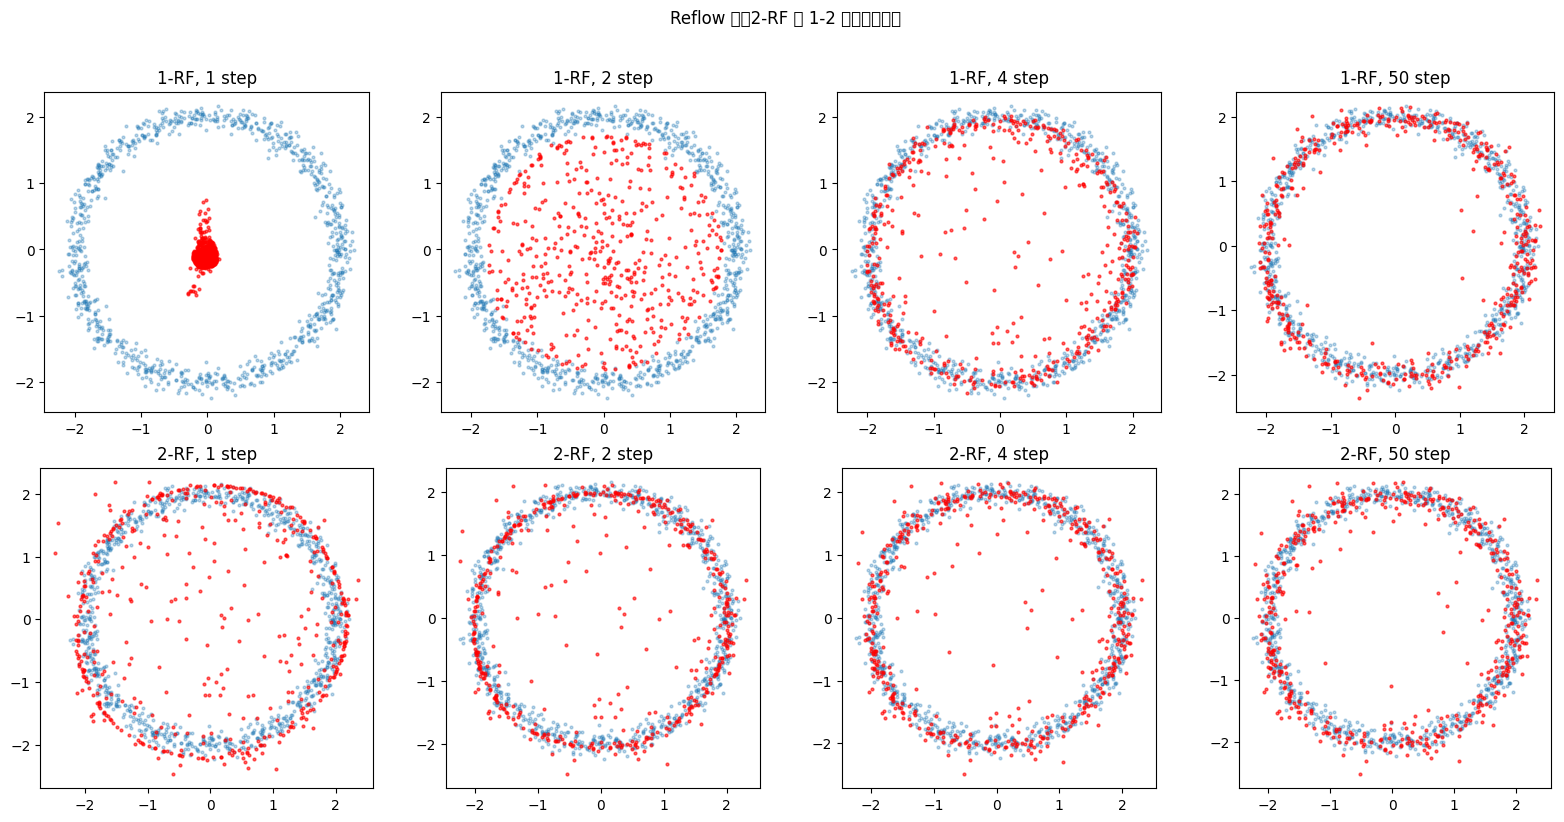

In [5]:
# ===== 对比 1-RF vs 2-RF 在 1/2/4 步下的效果 =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (v, name) in enumerate([(v1, '1-RF'), (v2, '2-RF')]):
    for col, n in enumerate(n_grid):
        x_gen = euler_sample(v, x0_test, n)
        ax = axes[row, col]
        ax.scatter(x1[:,0], x1[:,1], s=4, alpha=0.3)
        ax.scatter(x_gen[:,0], x_gen[:,1], s=4, alpha=0.6, c='r')
        ax.set_title(f'{name}, {n} step'); ax.set_aspect('equal')
plt.suptitle('Reflow 后：2-RF 在 1-2 步就能出环形', y=1.02); plt.tight_layout(); plt.show()

最后画出每个噪声点的完整轨迹——"路径变直"不用抽象理解，直接看线。

/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 24367 (\N{CJK UNIFIED IDEOGRAPH-5F2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476268/327787283.py:22: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/path/to/minifo

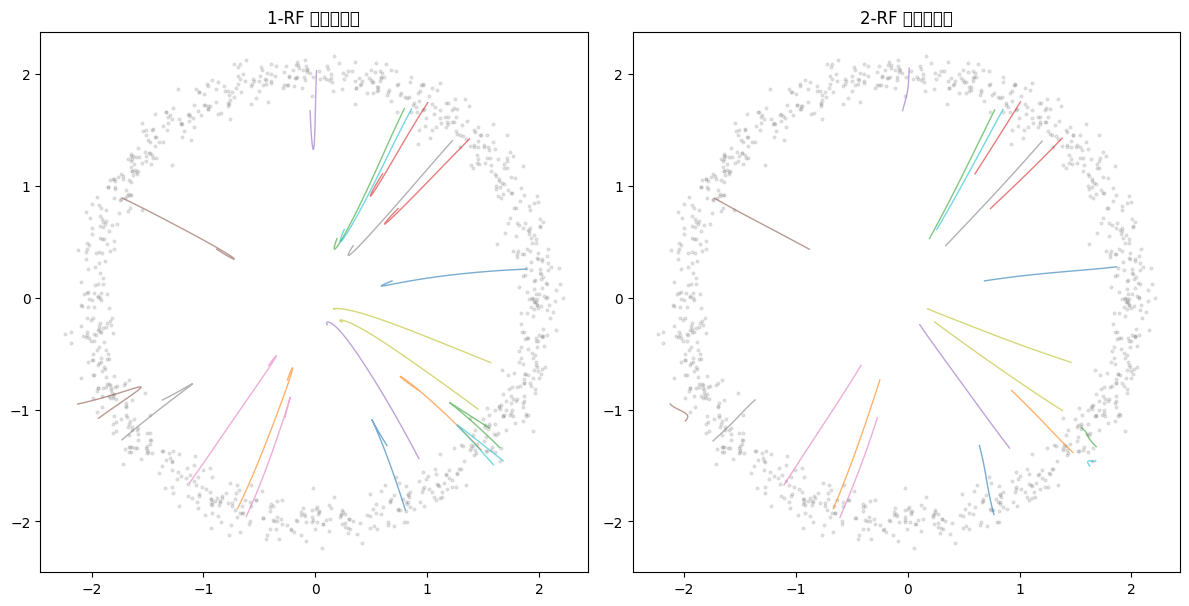

In [6]:
# ===== 可视化轨迹，直观看"路径变直" =====
@torch.no_grad()
def sample_with_trajectory(v, x0, n_steps=20):
    traj = [x0.clone()]
    x = x0.clone(); dt = 1.0/n_steps
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i*dt)
        x = x + dt * v(x, t)
        traj.append(x.clone())
    return torch.stack(traj)  # [T+1, N, 2]

x0_few = torch.randn(20, 2)
traj1 = sample_with_trajectory(v1, x0_few)
traj2 = sample_with_trajectory(v2, x0_few)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, traj, name in zip(axes, [traj1, traj2], ['1-RF 路径（弯）', '2-RF 路径（直）']):
    ax.scatter(x1[:,0], x1[:,1], s=4, alpha=0.2, c='gray')
    for i in range(20):
        ax.plot(traj[:,i,0], traj[:,i,1], '-', alpha=0.6, lw=1)
    ax.set_title(name); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Part 4 — SD3 的工程改动（面试加分点）

SD3 用的不是教科书版 Rectified Flow，有几个关键改动：

| 改动 | 原因 |
|------|------|
| **Logit-Normal 时间采样**（$t \sim \text{LogitNormal}(0, 1)$） | 训练时采样 $t$ 不再均匀，中间时刻更多。实证比均匀采样 FID 好 |
| **Timestep Shifting** | 高分辨率图像的信噪比曲线和低分辨率不一样，需要平移 $t$ 分布 |
| **MM-DiT 架构** | 文本和图像 token 拼一起做 attention（详见 09 DiT） |
| **没有显式 reflow** | 直接训一次，靠数据量 + Logit-Normal 采样把路径拉直 |

**面试注意**：如果面试官问"SD3 vs SDXL 核心区别"，第一句应该是 **"backbone 从 U-Net 换到 DiT，训练目标从 ε-pred（SDXL）/ v-pred（SD2.1）换到 Rectified Flow"**。这两个就是核心答案。

## Part 5 — 面试题

**Q1：Flow Matching 理论上不是就学直线路径吗？为什么还要 Rectified Flow？**
- 训练时随机配对 $(x_0, x_1)$，一个噪声点对应多个数据点，模型学到"平均方向"，实际路径是弯的。Rectified Flow 通过 reflow 用模型自己的采样结果做配对，消除一对多，路径真正变直。

**Q2：Reflow 一次就够了吗？**
- 理论上可以 k-Rectified Flow 递归，但每次都要采样整个数据集 + 重训，开销大。工业模型往往一次都不做（SD3 就没做 reflow），靠大数据量 + 技巧（Logit-Normal 时间采样）间接拉直。

**Q3：Rectified Flow 和 Consistency Models 的区别？**
- **RF**：先训"弯路径"再 reflow 训"直路径"，仍然需要多步采样（只是步数少）。路径上的所有中间态都要训练。
- **CM**：训一个"瞬移函数" $f(x_t, t) \to x_0$，任意 $t$ 直接跳到终点。是 1-step 生成的正解。RF 是 CM 的前置理解。

**Q4：为什么 SD3 要用 Logit-Normal 时间采样？**
- 训练时 $t$ 均匀分布会让模型对所有时刻"平均用力"。实证显示中间时刻（$t \approx 0.5$）的样本对学好向量场贡献最大。Logit-Normal 把更多 $t$ 集中在中间，训练效率高。

**Q5：如果业务需要 1 步生成，直接上 Rectified Flow 够吗？**
- 不够。RF 的极限大概 4 步能出像样结果。1 步要再做**蒸馏**（InstaFlow、DMD、LCM 等）。RF 是"走对方向"，蒸馏是"压缩步数"，两件事互补。